# LSZ Spectroscopy — main driver notebook

All physics, Fourier analysis, spectrum reconstruction, and state-vector validation live in `src/`. This notebook only wires them together.

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import qutip as qt

sys.path.append('/Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/lsz_spectroscopy/src')

from lsz_experiment import LSZ_experiment, run_experiment_sweep
from diagnostics import run_full_diagnostics

## Parameters

In [68]:
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

In [69]:
epsilon = 1
max_wait_time = 300
ramp_time = 2
n_steps = 201
dt = 0.01
r_noise = False
w_noise = False

# 2 qubit example (GHz)
# local_z_list = np.array([2.1, 1.1])
# local_x_list = np.array([0., 0.])
# zz_terms = np.array([0.35])
# t1_rates = [0.018, 0.012]
# t2_rates = [0.01, 0.015]
# assymetry_coefficients = [1,1]
# down_assymetry_coefficients = [1,1]
# n_qubits = len(local_z_list)
# psi0 = qt.tensor([1/np.sqrt(2)*(ket0 - ket1)]*n_qubits)


#Bell state example
local_z_list = np.array([1,1,1])
local_x_list = np.array([1, 1,1])
zz_terms = np.array([3,0,3])
t1_rates = [0., 0.]
t2_rates = [0., 0.]
assymetry_coefficients = [1, 2, 3]
down_assymetry_coefficients = [3, 2, 1]
n_qubits = len(local_z_list)

#Superposition Singlet
psi_p= 1/np.sqrt(2)*qt.tensor([ket1,ket0]) + 1/np.sqrt(2)*qt.tensor([ket0,ket1])
psi_m = 1/np.sqrt(2)*qt.tensor([ket1,ket0]) - 1/np.sqrt(2)*qt.tensor([ket0,ket1])
psi0 = 1/2*(qt.tensor([ket0,ket0]) + psi_p + psi_m + qt.tensor([ket1,ket1]))

psi0 = qt.tensor([1/np.sqrt(2)*(ket0 - ket1),1/np.sqrt(2)*(ket0 + ket1)])

psi0 = qt.tensor([1/np.sqrt(2)*(ket0 - ket1)]*n_qubits)


#GHZ state example
# local_z_list = np.array([0.1, -0.1])
# local_x_list = np.array([0.1, 0.1])
# zz_terms = np.array([-1])
# t1_rates = [0.018, 0.012]
# t2_rates = [0.01, 0.015]
# assymetry_coefficients = [1,100]
# down_assymetry_coefficients = [1,1]
# n_qubits = len(local_z_list)
# psi0 = qt.tensor([1/np.sqrt(2)*(ket0 + ket1)]*n_qubits)
# psi0 = qt.tensor([ket0, ket0])


#Superposition GHZ
# psi_p= 1/np.sqrt(2)*qt.tensor([ket1,ket1]) + 1/np.sqrt(2)*qt.tensor([ket0,ket0])
# psi_m = 1/np.sqrt(2)*qt.tensor([ket0,ket0]) - 1/np.sqrt(2)*qt.tensor([ket1,ket1])
# psi0 = 1/2*(qt.tensor([ket0,ket1]) + psi_p + psi_m + qt.tensor([ket1,ket0]))


#3 qubit example
# local_z_list = np.array([2.1, 3.05, 1.78])
# zz_terms = np.array([1.22, 0.54, 0.3])

# t1_rates = [0.005, 0.0051, 0.0048]
# t2_rates = [0.01, 0.012, 0.0098]

nqubits = len(local_z_list)
n_sims = int(max_wait_time*10)

tw_l = np.linspace(0, max_wait_time, n_sims)

H_target_dict = {'local_z': local_z_list, 'local_x': local_x_list, 'two_body': zz_terms}

print('Max wait time:', max_wait_time)
print('dt:', dt)
print('Number of simulations:', n_sims)

Max wait time: 300
dt: 0.01
Number of simulations: 3000


## Schedule and spectrum preview

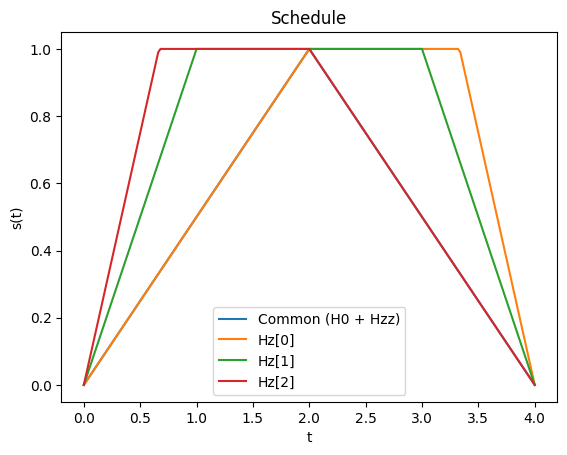

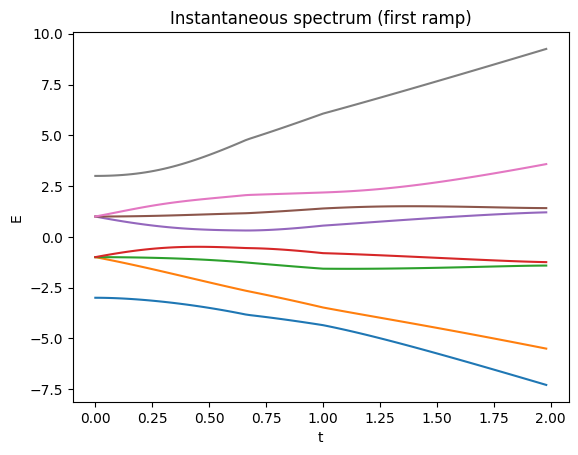

Spectrum at midpoint: [-7.35896962 -5.54904596 -1.41421356 -1.24922774  1.21162531  1.41421356
  3.62407804  9.32153998]

--- True transition frequencies ---
  f[0] = 1.809924
  f[1] = 5.944756
  f[2] = 6.109742
  f[3] = 8.570595
  f[4] = 8.773183
  f[5] = 10.983048
  f[6] = 16.680510
  f[7] = 4.134832
  f[8] = 4.299818
  f[9] = 6.760671
  f[10] = 6.963260
  f[11] = 9.173124
  f[12] = 14.870586
  f[13] = 0.164986
  f[14] = 2.625839
  f[15] = 2.828427
  f[16] = 5.038292
  f[17] = 10.735754
  f[18] = 2.460853
  f[19] = 2.663441
  f[20] = 4.873306
  f[21] = 10.570768
  f[22] = 0.202588
  f[23] = 2.412453
  f[24] = 8.109915
  f[25] = 2.209864
  f[26] = 7.907326
  f[27] = 5.697462

  Min peak separation: 0.037602

--- Eigenvectors at midpoint ---
  v[0]: [ 0.0178+0.j -0.124 +0.j -0.0436+0.j  0.0425+0.j -0.124 +0.j  0.9762+0.j
  0.0425+0.j -0.1024+0.j]
  v[1]: [-0.0692+0.j  0.0332+0.j  0.9409+0.j -0.2237+0.j  0.0332+0.j  0.0757+0.j
 -0.2237+0.j  0.0435+0.j]
  v[2]: [-0.    +0.j -0.2706+0.j  

In [70]:
preview = LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, 0, dt,
                         assymetry_factors=assymetry_coefficients,
                         down_assymetry_factors=down_assymetry_coefficients)

t_list, common_schedule, hz_schedules = preview.show_schedule(n_steps)
plt.plot(t_list, common_schedule, label='Common (H0 + Hzz)')
for i, hz_s in enumerate(hz_schedules):
    plt.plot(t_list, hz_s, label=f'Hz[{i}]')
plt.xlabel('t'); plt.ylabel('s(t)'); plt.title('Schedule')
plt.legend()
plt.show()

t_list, egvals, egvecs = preview.show_spectrum(n_steps)
midpoint = int(len(t_list)/2)
plt.plot(t_list[0:midpoint], egvals[0:midpoint])
plt.xlabel('t'); plt.ylabel('E'); plt.title('Instantaneous spectrum (first ramp)')
plt.show()

egvals_midpoint = egvals[midpoint]
print('Spectrum at midpoint:', egvals_midpoint)

freqs_true = []
for i, val_i in enumerate(egvals_midpoint[0:-1]):
    for val_j in egvals_midpoint[i+1:]:
     freqs_true.append(abs(val_j - val_i))

print("\n--- True transition frequencies ---")
for i, f in enumerate(freqs_true):
    print(f"  f[{i}] = {f:.6f}")

peak_separations = []
for i, val_i in enumerate(freqs_true[0:-1]):
    for val_j in freqs_true[i+1:]:
     peak_separations.append(abs(val_j - val_i))

print(f"\n  Min peak separation: {min(peak_separations):.6f}")

print("\n--- Eigenvectors at midpoint ---")
vecs = egvecs[midpoint]
for k, vec in enumerate(vecs.T):
    print(f"  v[{k}]: {np.array2string(vec, precision=4, suppress_small=True)}")

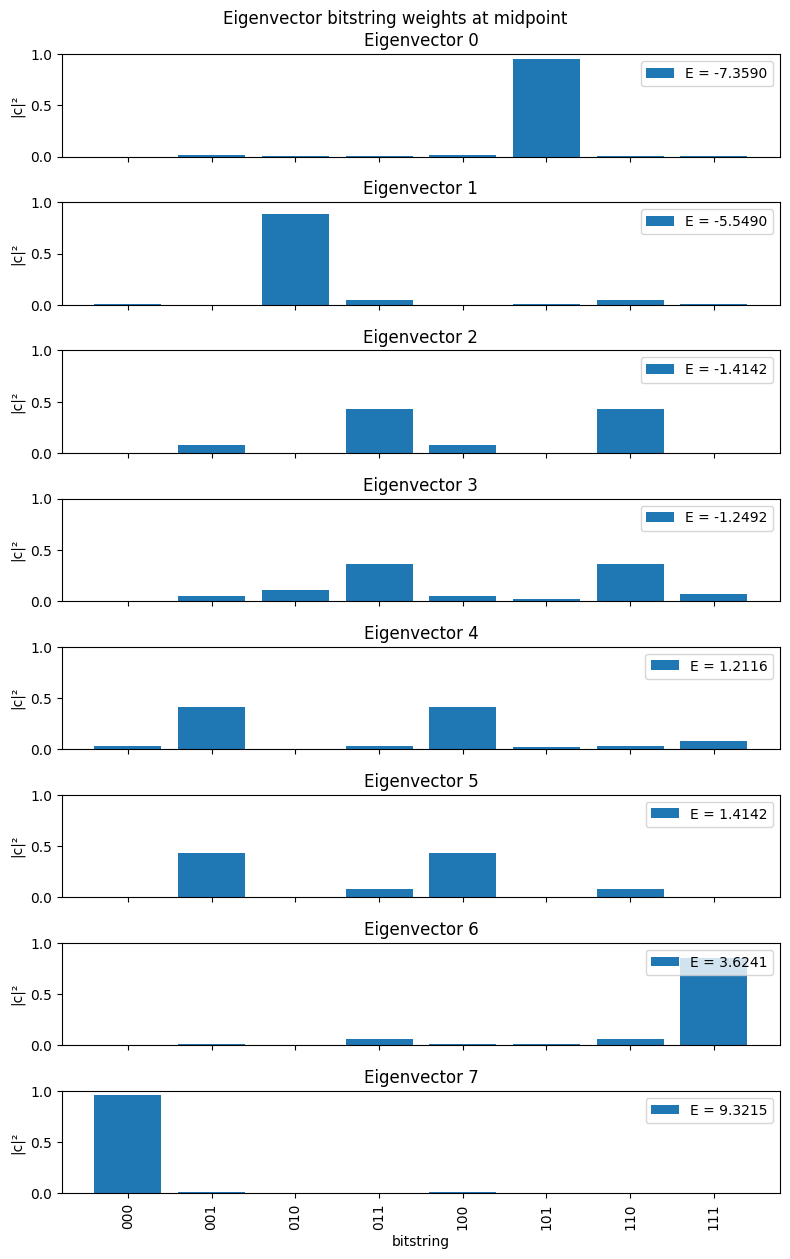

In [71]:
vecs_mid = np.asarray(egvecs[midpoint])
dim = vecs_mid.shape[0]
bitstrings = [format(i, f'0{nqubits}b') for i in range(dim)]
x = np.arange(dim)

fig, axes = plt.subplots(dim, 1, figsize=(max(6, dim), 1.6 * dim), sharex=True)
if dim == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    weights = np.abs(vecs_mid[:, k]) ** 2
    energy = egvals_midpoint[k]
    ax.bar(x, weights, label=f'E = {energy:.4f}')
    ax.set_ylabel(f'|c|²')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right')
    ax.set_title(f'Eigenvector {k}')
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(bitstrings, rotation=90)
axes[-1].set_xlabel('bitstring')
fig.suptitle('Eigenvector bitstring weights at midpoint')
fig.tight_layout()
plt.show()

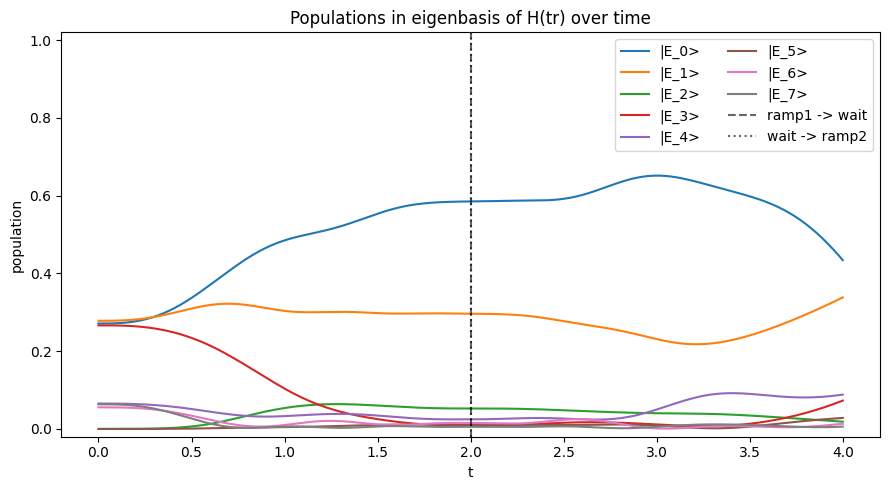

[0.58493802 0.29645467 0.05257663 0.00888847 0.02464118 0.01170967
 0.01531846 0.00547291]


In [72]:
sample_wait = 0
evo = LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, sample_wait, dt,
                     assymetry_factors=assymetry_coefficients,
                     down_assymetry_factors=down_assymetry_coefficients,
                     initial_state=psi0)
sim_r1, sim_w, sim_r2 = evo.time_evolution()

pops_r1 = evo.calculate_eigenbasis_populations(sim_r1)
pops_w  = evo.calculate_eigenbasis_populations(sim_w)
pops_r2 = evo.calculate_eigenbasis_populations(sim_r2)

t_all = np.concatenate([sim_r1.times, sim_w.times, sim_r2.times])
pops_all = np.concatenate([pops_r1, pops_w, pops_r2], axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
for k in range(pops_all.shape[1]):
    ax.plot(t_all, pops_all[:, k], label=f'|E_{k}>')

ax.axvline(evo.tr,          color='k', linestyle='--', alpha=0.6, label='ramp1 -> wait')
ax.axvline(evo.tr + evo.tw, color='k', linestyle=':',  alpha=0.6, label='wait -> ramp2')

ax.set_xlabel('t')
ax.set_ylabel('population')
ax.set_title('Populations in eigenbasis of H(tr) over time')
ax.set_ylim(-0.02, 1.02)
ax.legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()

print(pops_r1[-1])

## Run the experiment sweep

In [73]:
pc_list = run_experiment_sweep(
    nqubits, epsilon, H_target_dict, ramp_time, tw_l, dt,
    assym_list=assymetry_coefficients,
    down_assym_list=down_assymetry_coefficients,
    r_noise=r_noise, w_noise=w_noise,
    gamma_dec_list=t1_rates, gamma_dep_list=t2_rates, initial_state=psi0
)

## Full diagnostics

Fourier analysis + global fit + energy-difference matching + turnpike reconstruction + u_m / phi_m recovery + exact-state validation + (optional) dephasing comparison.

[round 0] f=0.288058  A=0.1735  lam=0.0000  phi=3.162
[round 1] f=0.946150  A=0.0308  lam=0.0000  phi=4.633
[round 2] f=0.658093  A=0.0156  lam=0.0000  phi=1.471
[round 3] f=1.364029  A=0.0143  lam=0.0000  phi=1.412
[round 4] f=1.748001  A=0.0090  lam=0.0000  phi=1.698
[round 5] f=1.075945  A=0.0073  lam=0.0001  phi=4.555
[round 6] f=1.396327  A=0.0068  lam=0.0000  phi=2.175
[round 7] f=0.972410  A=0.0052  lam=0.0000  phi=1.396
[round 8] f=1.459948  A=0.0046  lam=0.0000  phi=4.812
[round 9] f=1.108231  A=0.0035  lam=0.0000  phi=5.329
[round 10] f=2.654784  A=0.0032  lam=0.0000  phi=1.654
[round 11] f=0.684333  A=0.0026  lam=0.0000  phi=4.533
[round 12] f=2.366728  A=0.0016  lam=0.0000  phi=4.771
[round 13] f=0.417879  A=0.0013  lam=0.0001  phi=3.066
[round 14] f=0.801854  A=0.0008  lam=0.0000  phi=3.343
[round 15] f=0.450101  A=0.0006  lam=0.0000  phi=3.901
[round 16] f=0.026423  A=0.0005  lam=0.0004  phi=2.915
[round 17] f=0.383885  A=0.0004  lam=0.0000  phi=0.404
[round 18] f=0.03227

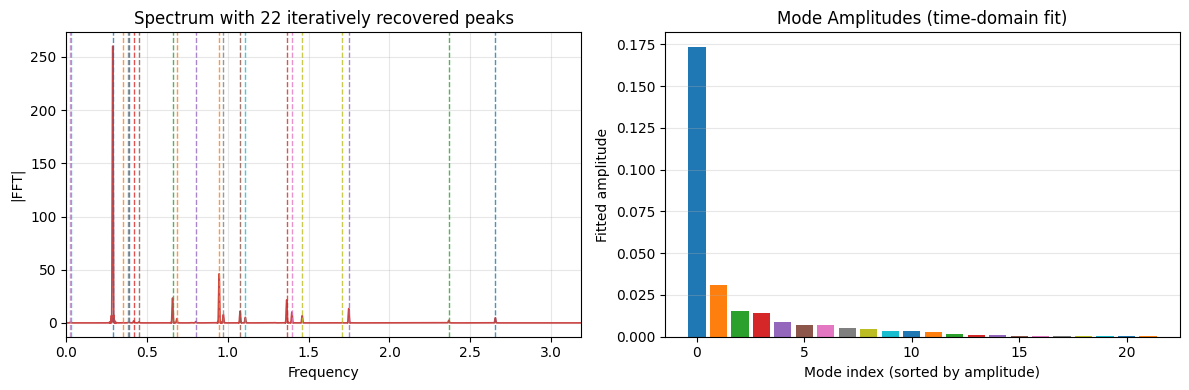


  #       Frequency   Phase (rad)         Amp      Lambda
------------------------------------------------------------
  1        0.288058        3.1623     0.17355     0.00001
  2        0.946150        4.6332     0.03079     0.00000
  3        0.658093        1.4707     0.01562     0.00000
  4        1.364029        1.4125     0.01427     0.00000
  5        1.748001        1.6983     0.00899     0.00001
  6        1.075945        4.5551     0.00730     0.00009
  7        1.396327        2.1748     0.00682     0.00000
  8        0.972410        1.3958     0.00523     0.00005
  9        1.459948        4.8121     0.00455     0.00001
 10        1.108231        5.3288     0.00346     0.00000
 11        2.654784        1.6540     0.00321     0.00003
 12        0.684333        4.5325     0.00263     0.00000
 13        2.366728        4.7706     0.00162     0.00000
 14        0.417879        3.0658     0.00130     0.00005
 15        0.801854        3.3428     0.00081     0.00000
 16       

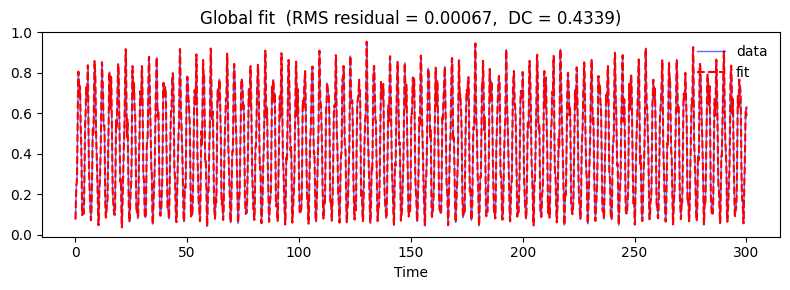

Amplitudes: [0.17341585 0.03076206 0.01559224 0.0144093  0.00896032 0.00730656
 0.00684142 0.00518291 0.0045433  0.00346683 0.0031967  0.00262703
 0.00162103 0.00130595 0.00080602 0.00061662 0.00046707 0.00037637
 0.00028771 0.00027741 0.00021275 0.00017841]
Decay rates: [1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12
 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12
 1.e-12 1.e-12]
DC (fitted): 0.4338537923800048   DC (mean): 0.4334919370859563

                     Matched energy differences                     
--------------------------------------------------------------------
   #     Detected Δε         True Δε           Error       Error (%)
--------------------------------------------------------------------
   1        1.809921        1.809924       -0.000002          -0.000%
   2        5.944834        5.944756       +0.000078          +0.001%
   3        4.134918        4.134832       +0.000086          +0.002%
   4        8.57044

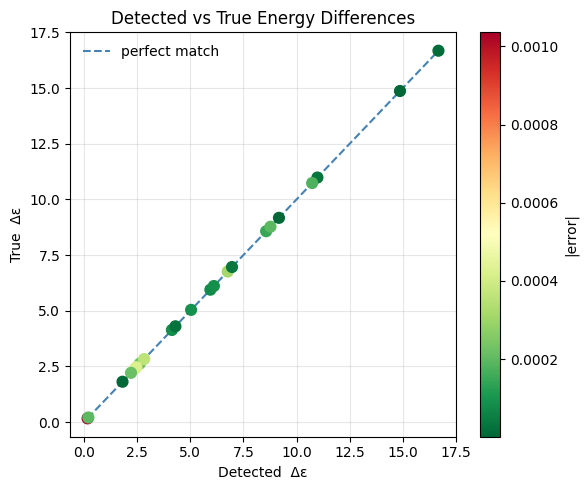

Incomplete Turnpike Solver
  Target levels:        8
  Expected differences: 28
  Observed differences: 22 (79%)

  Trying match threshold = 100% ... no solution at this threshold.
  Trying match threshold = 80% ... no solution at this threshold.
  Trying match threshold = 60% ... no solution at this threshold.
  Trying match threshold = 40% ... no solution at this threshold.
  Trying match threshold = 20% ... found solution explaining 13/22 (59%) of observations.

  Running greedy solver for comparison...
  Greedy explains 16/22 (73%)

  Final solution (greedy_fallback):
    [np.float64(0.0), np.float64(1.8099), np.float64(1.8102), np.float64(5.9449), np.float64(8.5705), np.float64(8.7733), np.float64(10.983), np.float64(16.6805)]
    Explains 16/22 observed differences (73%)

                  E0      E1      E2      E3      E4      E5      E6      E7
True:         0.0000  1.8099  5.9448  6.1097  8.5706  8.7732 10.9830 16.6805
Forward:      0.0000  1.8099  1.8102  5.9449  8.5705  8.7

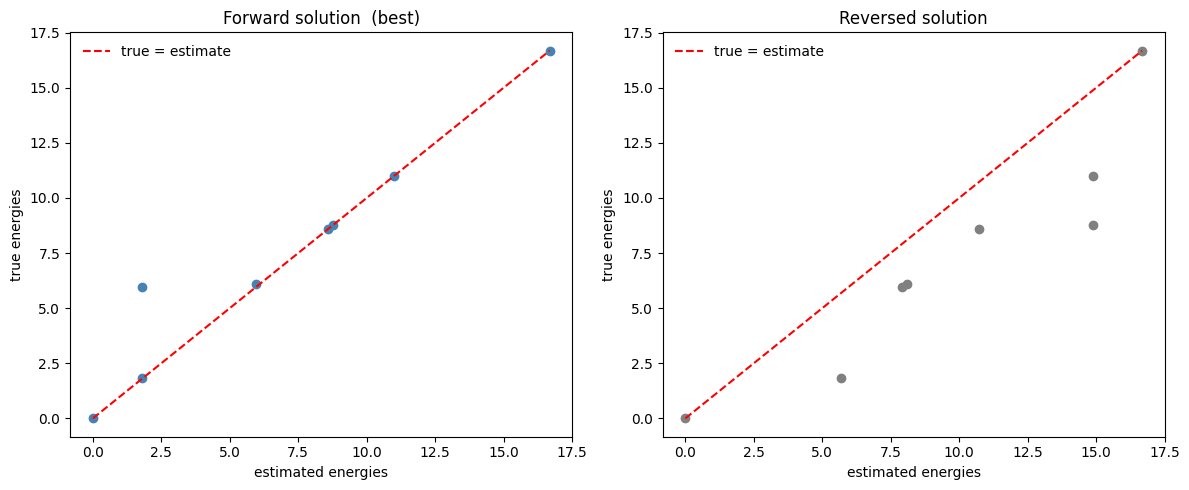

e_m:   [ 0.      1.8099  2.2096  5.9448  8.5704  8.7734 10.983  16.6805]
phi_m: [0.     1.5605 0.2487 0.825  2.4354 2.0542 2.2924 2.3146]
u_m:   [0.7633 0.5445 0.0975 0.2294 0.1771 0.122  0.1238 0.1407]
Exact |u_m|: [0.76481241 0.54447651 0.22929595 0.09427868 0.1569751  0.10821122
 0.12376775 0.07397911]
Exact phases (mod pi, rel to u_0): [0.         1.56055131 2.38930044 2.43685637 2.44864    0.46935251
 2.29467916 2.31596034]


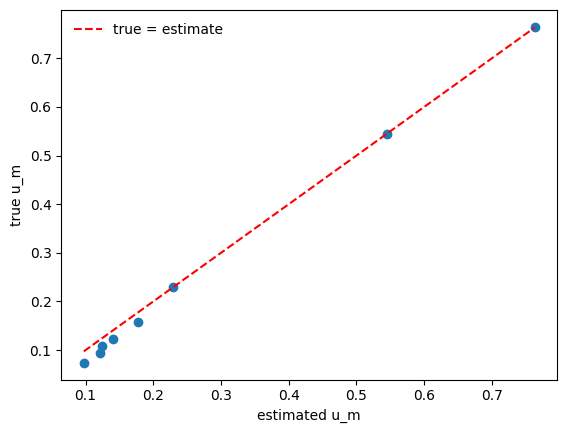

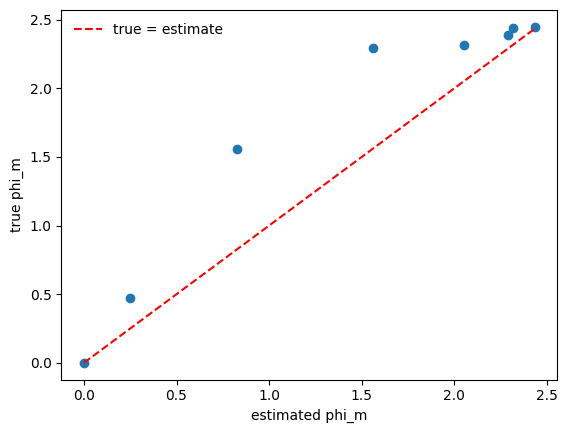

In [74]:
results = run_full_diagnostics(
    pc_list, tw_l, nqubits, epsilon, H_target_dict,
    ramp_time, dt, egvals_midpoint,
    w_noise=w_noise,
    t1_rates=t1_rates if w_noise else None,
    t2_rates=t2_rates if w_noise else None,
    initial_state=psi0,
    assym_list=assymetry_coefficients,
    down_assym_list=down_assymetry_coefficients,
)

## Joint refinement (warm-start + nonlinear LS)

Stage A estimates the diagonal populations {v_S} from the residual after
subtracting the oscillatory model. Stage B does a joint nonlinear LS fit
of all physical parameters (|u_m|, phi_m, E_m, kappa_phi_q, kappa_T1_q, v_S)
to the time-domain signal, warm-started from the diagnostics output.

`ftol` termination condition is satisfied.
Function evaluations 80, initial cost 2.4177e+02, final cost 8.6600e-01, first-order optimality 9.50e-06.
Joint refinement summary
converged: True    n_fev = 80    cost (data) = 8.6600e-01    cost (reg) = 0.0000e+00
message: `ftol` termination condition is satisfied.

-- Eigenstate labels (bitstrings) --
  ['101', '010', '011', '110', '100', '001', '111', '000']

-- State-vector moduli |u_m| --
       |u_m|   warm: [0.7548 0.5385 0.0964 0.2268 0.1751 0.1207 0.1224 0.1391]
               refn: [0.7646 0.5452 0.1701 0.2296 0.0658 0.1056 0.1242 0.0741]
               true: [0.7648 0.5445 0.2293 0.0943 0.157  0.1082 0.1238 0.074 ]
               |refn-true|: [0.0002 0.0008 0.0592 0.1353 0.0912 0.0026 0.0005 0.0001]

-- Phases phi_m --
       phi_m   warm: [0.     1.5605 0.2487 0.825  2.4354 2.0542 2.2924 2.3146]
               refn: [ 0.      1.6296  0.8083 -0.8324  3.1416  1.0787  0.8474  0.8245]
               true: [0.     1.5606 2.3893 2.4369 

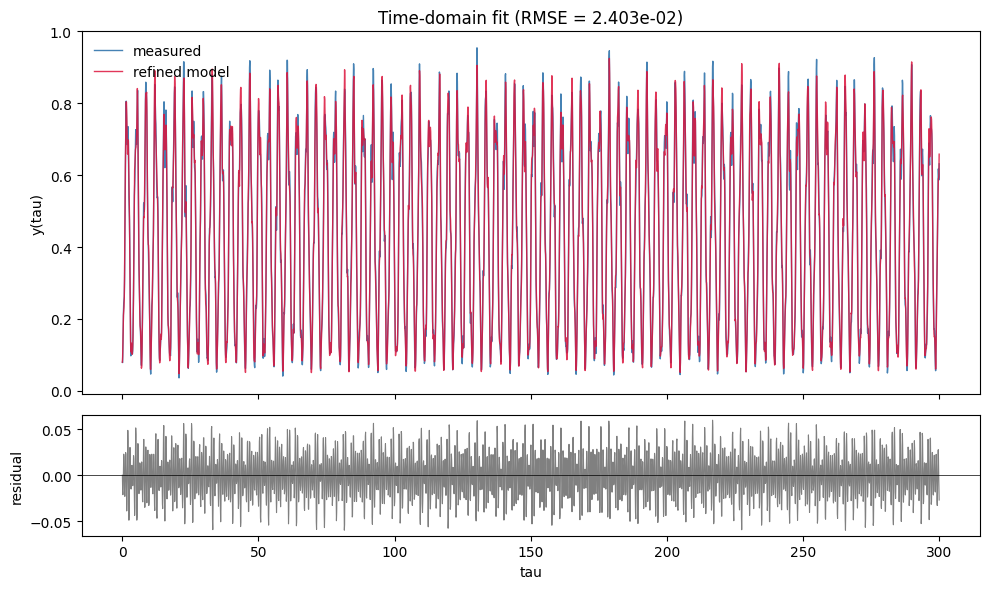

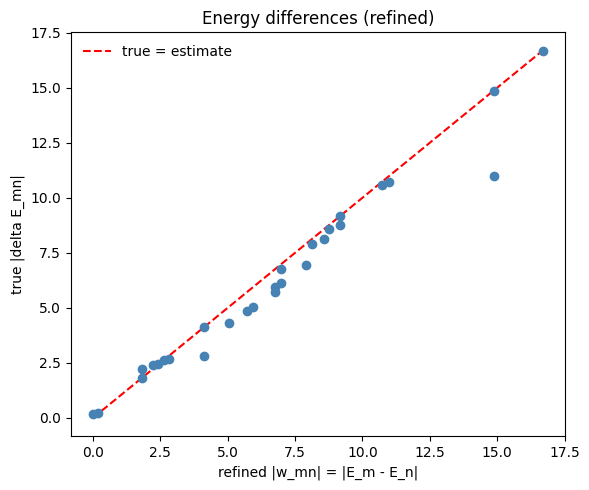

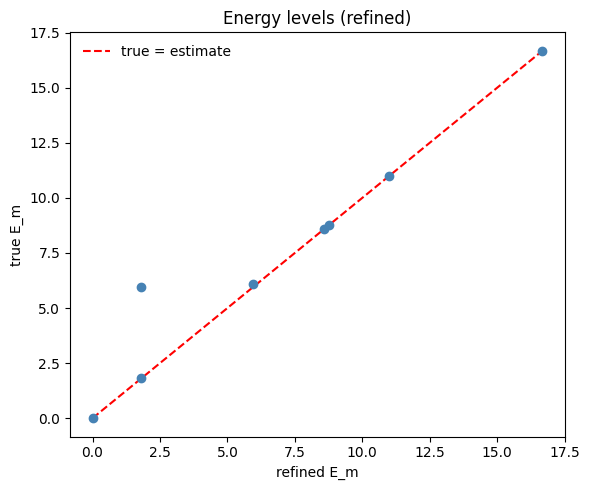

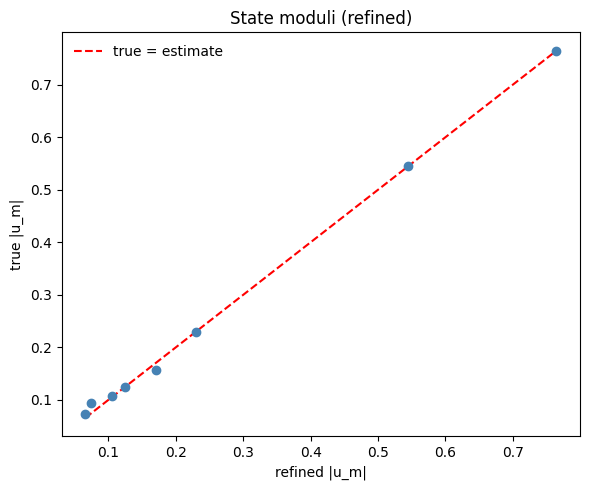

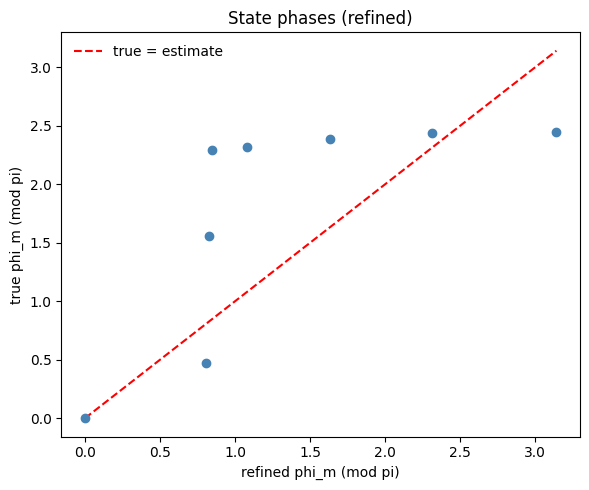

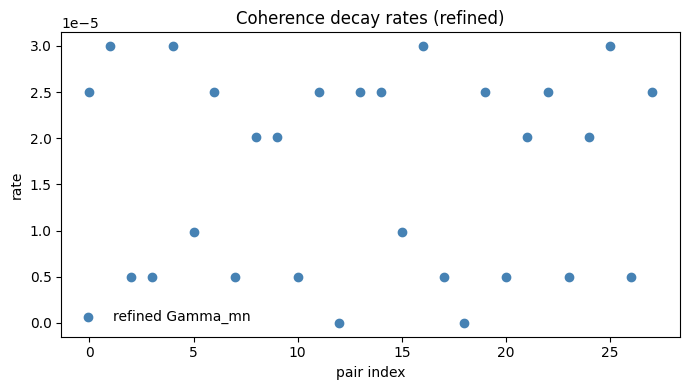

{'rmse': 0.024027737325824024,
 'y_model': array([0.07944468, 0.09495358, 0.13872221, ..., 0.59097637, 0.60086465,
        0.6583653 ], shape=(3000,)),
 'derived': {'y_model': array([0.07944468, 0.09495358, 0.13872221, ..., 0.59097637, 0.60086465,
         0.6583653 ], shape=(3000,)),
  'y_osc': array([-0.35561266, -0.34010334, -0.29633428, ...,  0.15720229,
          0.16709099,  0.22459207], shape=(3000,)),
  'y_pop': array([0.43505735, 0.43505692, 0.43505649, ..., 0.43377408, 0.43377365,
         0.43377323], shape=(3000,)),
  'a_mn': array([[0.00000000e+00, 1.73815664e-01, 1.69139016e-02, 3.08200767e-02,
          2.53186278e-03, 6.51795181e-03, 9.02304767e-03, 3.20696496e-03],
         [0.00000000e+00, 0.00000000e+00, 8.59998599e-03, 1.56706734e-02,
          1.28734251e-03, 3.31409605e-03, 4.58782873e-03, 1.63060271e-03],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.52490415e-03,
          1.25270553e-04, 3.22492766e-04, 4.46438956e-04, 1.58673005e-04],
         [0

In [75]:
from refinement import run_refinement, print_refinement_summary, plot_refined_diagnostics

refine_results = run_refinement(
    results, tw_l, pc_list,
    reg=None,
    max_nfev=500,
    verbose=1,
    freeze_E=True,
    population_mode="subsets",    # "dc": single scalar baseline like fit_decay_rates. Use "subsets" for the full v_S Markov sector, or "off" to drop it entirely.
    x_scale="auto",          # per-block scaling -> sensible step sizes for rates
    loss="linear",           # match the global fit; switch to "soft_l1" if noise is heavy
    f_scale=1.0,             # transition scale for robust losses (unused for "linear")
    anchor_kappa_weight=0.0, # set > 0 (e.g. 1e3) to pin (kphi, kT1) near NNLS warm-start
    keep_warm_if_worse=True, # safeguard: revert if data cost increases
)

# Build a truth dict (only available because this is a simulator run).
truth = {
    'u_abs': results['u_exact_amplitudes'],
    'phi':   results['u_exact_phases_rel'],
    'kphi':  np.asarray(t2_rates) if w_noise else None,
    'kT1':   np.asarray(t1_rates) if w_noise else None,
}

print_refinement_summary(refine_results, truth=truth)

plot_refined_diagnostics(
    refine_results, results, tw_l, pc_list,
    exact_lambdas=results.get('exact_lambdas'),
)

In [76]:
"""
Forward calculation of coherence decay rates Gamma_{mn} from per-qubit
T1 and T2_phi (pure dephasing) times.

This is the inverse companion to extract_rates.py: given the underlying
per-qubit decoherence parameters, predict what coherence decay rates one
should observe in the LZS signal. Useful for:

  - Validating the structural formula before fitting real data.
  - Generating synthetic test data for the rate-extraction pipeline.
  - Sanity-checking extracted rates by re-predicting and comparing
    to observed Gamma_{mn}.

The formula being implemented is:

    Gamma_{mn} = sum_q [ kappa_phi_q * d_q(m,n)
                        + (1/2) * kappa_T1_q * (e_q(m) + e_q(n)) ]

where, with the convention 0 -> |0> (z=+1), 1 -> |1> (z=-1):

    d_q(m,n) = 1 if qubits m,n disagree on bit q, else 0
    e_q(m)   = 1 if qubit q is excited (|1>) in state m, else 0

    kappa_phi_q = 1 / T2_phi_q   (pure dephasing rate of qubit q)
    kappa_T1_q  = 1 / T1_q       (amplitude damping rate of qubit q)

For a single qubit this reduces to the textbook
    Gamma_{0,1} = 1/(2 T1) + 1/T2_phi.
"""

import numpy as np
from itertools import combinations, product


def enumerate_bitstrings(N_q):
    """
    Enumerate all 2^N_q computational basis states as 0/1 bitstrings.
    Convention: leftmost bit = qubit 1 = most significant.

    Returns: (2^N_q, N_q) array, row m gives the bitstring of state |m>.
    """
    return np.array([[(m >> (N_q - 1 - q)) & 1 for q in range(N_q)]
                     for m in range(2 ** N_q)], dtype=int)


def predict_gamma_rates(T1_list, T2_phi_list, return_breakdown=False):
    """
    Predict coherence decay rates Gamma_{mn} for all pairs of computational
    basis states, given per-qubit T1 and pure-dephasing T2_phi times.

    Parameters
    ----------
    T1_list : array_like of length N_q
        Amplitude damping times for each qubit. Units: time (e.g. microseconds).
        Use np.inf for a qubit with no T1 decay.
    T2_phi_list : array_like of length N_q
        Pure dephasing times for each qubit (NOT total T2 -- this is the
        contribution beyond the T1-induced dephasing). Units: same as T1.
        Use np.inf for a qubit with no pure dephasing.
    return_breakdown : bool
        If True, also return separate dephasing and amplitude-damping
        contributions for diagnostic purposes.

    Returns
    -------
    Gamma : dict {(m, n): rate}
        Total coherence decay rate for each pair m < n.
        Keys are tuples of state indices, values are rates in 1/(time unit).
    breakdown : dict (only if return_breakdown=True)
        {'dephasing': {(m,n): rate}, 'amp_damping': {(m,n): rate}}
    """
    T1 = np.asarray(T1_list, dtype=float)
    T2_phi = np.asarray(T2_phi_list, dtype=float)
    if T1.shape != T2_phi.shape:
        raise ValueError("T1_list and T2_phi_list must have the same length")

    N_q = T1.size
    # Use safe inversion: 1/inf = 0, leaving qubits without that decay channel.
    kappa_T1 = np.where(np.isfinite(T1) & (T1 > 0), 1.0 / T1, 0.0)
    kappa_phi = np.where(np.isfinite(T2_phi) & (T2_phi > 0), 1.0 / T2_phi, 0.0)

    bitstrings = enumerate_bitstrings(N_q)  # shape (2^N_q, N_q)
    M = bitstrings.shape[0]

    Gamma = {}
    deph = {}
    amp = {}

    for m, n in combinations(range(M), 2):
        bm = bitstrings[m]
        bn = bitstrings[n]

        # Dephasing contribution: rate per qubit where the two states disagree.
        d = (bm != bn).astype(float)
        gamma_phi = float(np.sum(kappa_phi * d))

        # Amplitude damping contribution: rate per qubit, weighted by
        # (excited-in-m) + (excited-in-n), times 1/2.
        e_sum = bm.astype(float) + bn.astype(float)
        gamma_T1 = 0.5 * float(np.sum(kappa_T1 * e_sum))

        Gamma[(m, n)] = gamma_phi + gamma_T1
        deph[(m, n)] = gamma_phi
        amp[(m, n)] = gamma_T1

    if return_breakdown:
        return Gamma, {'dephasing': deph, 'amp_damping': amp}
    return Gamma


def predict_T1_eigenvalues(T1_list):
    """
    Predict the 2^N_q eigenvalues of the population Markov-chain rate matrix W
    under independent amplitude damping. These are the decay rates that
    appear in the zero-frequency Lorentzian fit.

    Each subset S of {1,...,N_q} contributes mu_S = sum_{q in S} kappa_T1_q.

    Parameters
    ----------
    T1_list : array_like of length N_q

    Returns
    -------
    eigenvalues : dict {frozenset(qubit indices): mu_S}
        The empty subset gives mu = 0 (steady state).
    """
    T1 = np.asarray(T1_list, dtype=float)
    N_q = T1.size
    kappa_T1 = np.where(np.isfinite(T1) & (T1 > 0), 1.0 / T1, 0.0)

    eigenvalues = {}
    for mask in range(2 ** N_q):
        S = frozenset(q for q in range(N_q) if (mask >> q) & 1)
        eigenvalues[S] = float(sum(kappa_T1[q] for q in S))
    return eigenvalues


# -----------------------------------------------------------------------------
# Validation against direct Lindblad simulation
# -----------------------------------------------------------------------------

def lindblad_decay_rates_numeric(T1_list, T2_phi_list):
    """
    Directly evaluate the decay rate of each coherence rho_{mn} under
    independent per-qubit Lindblad dissipators

        L_phi,q = sqrt(kappa_phi_q / 2) * sigma_z[q]   (pure dephasing)
        L_T1,q  = sqrt(kappa_T1_q)      * sigma_-[q]   (amplitude damping)

    With this normalization the dephasing dissipator gives a coherence
    decay rate of kappa_phi_q per disagreeing qubit, matching the
    structural formula above and the textbook single-qubit 1/T2 =
    1/(2 T1) + 1/T2_phi.

    Returns dict {(m,n): rate} computed directly from the Lindbladian.
    """
    T1 = np.asarray(T1_list, dtype=float)
    T2_phi = np.asarray(T2_phi_list, dtype=float)
    N_q = T1.size
    M = 2 ** N_q
    kappa_T1 = np.where(np.isfinite(T1) & (T1 > 0), 1.0 / T1, 0.0)
    kappa_phi = np.where(np.isfinite(T2_phi) & (T2_phi > 0), 1.0 / T2_phi, 0.0)

    bitstrings = enumerate_bitstrings(N_q)
    rates = {}

    for m, n in combinations(range(M), 2):
        bm = bitstrings[m]
        bn = bitstrings[n]
        # Amplitude damping anticommutator on rho_{mn}.
        gamma_amp = 0.5 * np.sum(kappa_T1 * (bm + bn))

        # Pure dephasing on rho_{mn}: (1 - z_m z_n)/2 in {0,1} is the
        # disagreement indicator, and the Lindblad prefactor 1/2 (from the
        # sqrt(kappa_phi/2) normalization) absorbs the textbook factor.
        z_m = 1 - 2 * bm
        z_n = 1 - 2 * bn
        gamma_deph = 0.5 * np.sum(kappa_phi * (1 - z_m * z_n))

        rates[(m, n)] = float(gamma_amp + gamma_deph)
    return rates


# -----------------------------------------------------------------------------
# Self-test / demonstration
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    # # Test parameters: 3 qubits with distinct T1 and T2_phi.
    # T1_list = [10.0, 8.0, 12.0]              # microseconds
    # T2_phi_list = [3.0, 5.0, 4.0]            # microseconds (pure dephasing)
    T1_list = [120, 150]
    T2_phi_list = [110, 100]
    N_q = len(T1_list)

    print(f"Test case: N_q = {N_q}")
    print(f"  T1 (us)     = {T1_list}")
    print(f"  T2_phi (us) = {T2_phi_list}")
    print(f"  kappa_T1   (1/us) = {[1/t for t in T1_list]}")
    print(f"  kappa_phi  (1/us) = {[1/t for t in T2_phi_list]}")
    print()

    # Predict Gamma rates from the structural formula
    Gamma, parts = predict_gamma_rates(T1_list, T2_phi_list,
                                        return_breakdown=True)

    # Cross-check against direct Lindblad evaluation
    Gamma_numeric = lindblad_decay_rates_numeric(T1_list, T2_phi_list)

    bitstrings = enumerate_bitstrings(N_q)
    state_labels = ["".join(str(b) for b in bitstrings[m])
                    for m in range(2**N_q)]

    print("Predicted Gamma_{m,n} rates (formula vs. direct Lindblad):")
    print(f"{'(m,n)':<10} {'states':<14} {'deph':<10} {'amp':<10} "
          f"{'total':<10} {'numeric':<10} {'diff':<10}")
    print("-" * 80)
    max_diff = 0.0
    for (m, n), g in Gamma.items():
        g_num = Gamma_numeric[(m, n)]
        diff = abs(g - g_num)
        max_diff = max(max_diff, diff)
        label = f"|{state_labels[m]}>,|{state_labels[n]}>"
        print(f"({m},{n}){'':<5} {label:<14} "
              f"{parts['dephasing'][(m,n)]:<10.4f} "
              f"{parts['amp_damping'][(m,n)]:<10.4f} "
              f"{g:<10.4f} {g_num:<10.4f} {diff:<10.2e}")

    print(f"\nMax discrepancy formula vs. direct Lindblad: {max_diff:.2e}")
    if max_diff < 1e-10:
        print("Formula validated against direct Lindblad evaluation.")
    else:
        print("WARNING: discrepancy detected -- formula may be miscoded.")

    # Also report the population-sector eigenvalues
    print("\nMarkov-chain eigenvalues mu_S (zero-peak Lorentzian widths):")
    eigvals = predict_T1_eigenvalues(T1_list)
    for S, mu in sorted(eigvals.items(), key=lambda kv: kv[1]):
        S_str = "{" + ",".join(f"q{q+1}" for q in sorted(S)) + "}" if S else "{}"
        print(f"  S = {S_str:<20}  mu_S = {mu:.4f} 1/us")

    # Sanity check: a single qubit's coherence between |0> and |1> should
    # decay at the textbook rate 1/T2 = 1/(2 T1) + 1/T2_phi.
    print("\nSingle-qubit consistency check (qubit 1 isolated):")
    Gamma_q1, _ = predict_gamma_rates([T1_list[0]], [T2_phi_list[0]],
                                       return_breakdown=True)
    g_pred = Gamma_q1[(0, 1)]
    g_textbook = 1 / (2 * T1_list[0]) + 1 / T2_phi_list[0]
    print(f"  Predicted Gamma_{{0,1}} = {g_pred:.4f} 1/us")
    print(f"  Textbook 1/(2T1)+1/T2phi = {g_textbook:.4f} 1/us")
    print(f"  Match: {abs(g_pred - g_textbook) < 1e-12}")

Test case: N_q = 2
  T1 (us)     = [120, 150]
  T2_phi (us) = [110, 100]
  kappa_T1   (1/us) = [0.008333333333333333, 0.006666666666666667]
  kappa_phi  (1/us) = [0.00909090909090909, 0.01]

Predicted Gamma_{m,n} rates (formula vs. direct Lindblad):
(m,n)      states         deph       amp        total      numeric    diff      
--------------------------------------------------------------------------------
(0,1)      |00>,|01>      0.0100     0.0033     0.0133     0.0133     0.00e+00  
(0,2)      |00>,|10>      0.0091     0.0042     0.0133     0.0133     0.00e+00  
(0,3)      |00>,|11>      0.0191     0.0075     0.0266     0.0266     0.00e+00  
(1,2)      |01>,|10>      0.0191     0.0075     0.0266     0.0266     0.00e+00  
(1,3)      |01>,|11>      0.0091     0.0108     0.0199     0.0199     0.00e+00  
(2,3)      |10>,|11>      0.0100     0.0117     0.0217     0.0217     0.00e+00  

Max discrepancy formula vs. direct Lindblad: 0.00e+00
Formula validated against direct Lindblad evalu